In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/customer_churn.csv')

In [5]:
df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [7]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

No null values

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df.duplicated()]

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn


No duplicate values

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


Need to change the format for Onboard_date - str to datetime64[us]

In [11]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'], format='mixed', dayfirst=True)

Changed Onboard_date     900 non-null    datetime64[us]

In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Names            900 non-null    str           
 1   Age              900 non-null    float64       
 2   Total_Purchase   900 non-null    float64       
 3   Account_Manager  900 non-null    int64         
 4   Years            900 non-null    float64       
 5   Num_Sites        900 non-null    float64       
 6   Onboard_date     900 non-null    datetime64[us]
 7   Location         900 non-null    str           
 8   Company          900 non-null    str           
 9   Churn            900 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(3)
memory usage: 70.4 KB


find the outliers

In [13]:
df.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1


In [14]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885


check for 
min	22.000000	100.000000	0.000000	1.000000	3.000000	2006-01-03 07:20:00	0.000000


<Axes: xlabel='Total_Purchase', ylabel='Count'>

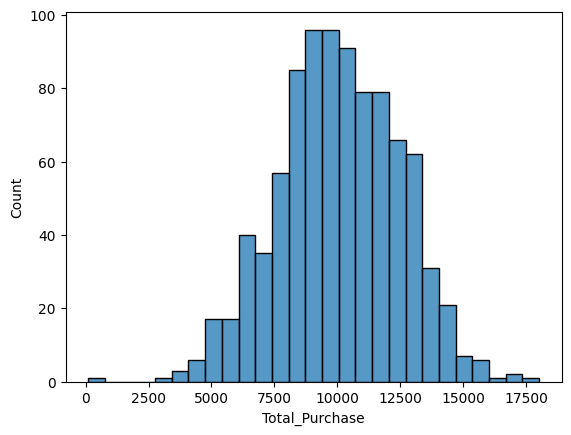

In [15]:
sns.histplot(df['Total_Purchase'])

In [16]:
df.sort_values(by='Total_Purchase').head(5)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
659,Kayla Reeves,38.0,100.00,0,5.27,5.0,2006-03-10 09:01:48,"1511 Porter Drive Amberberg, NC 44608",Stewart-Lopez,0
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0
777,Kathleen Marquez,35.0,3825.70,0,4.28,8.0,2006-05-15 18:02:51,"984 Gallagher Circle Port Gregorytown, MD 59029","Steele, Nguyen and Lewis",0


only outlier- 	Names	Age	Total_Purchase	Account_Manager	Years	Num_Sites	Onboard_date	Location	Company	Churn
659	Kayla Reeves	38.0	100.00	0	5.27	5.0	2006-03-10 09:01:48	1511 Porter Drive Amberberg, NC 44608	Stewart-Lopez	0

In [17]:
df = df.drop(659)

In [18]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn
count,899.000000,899.000000,899.000000,899.000000,899.000000,899,899.000000
mean,41.820912,10073.906151,0.481646,5.273159,8.591769,2011-04-19 00:20:37.614015,0.166852
min,22.000000,3263.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000
25%,38.000000,8508.135000,0.000000,4.450000,7.000000,2008-07-01 19:32:54.500000,0.000000
50%,42.000000,10050.610000,0.000000,5.210000,8.000000,2011-03-28 01:58:13,0.000000
75%,46.000000,11761.520000,1.000000,6.110000,10.000000,2014-02-24 22:13:10.500000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000
std,6.129647,2386.917245,0.499941,1.275158,1.761750,NaN,0.373051


<Axes: xlabel='Total_Purchase', ylabel='Count'>

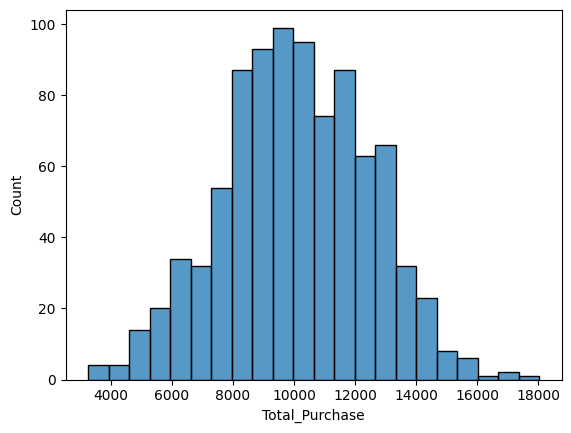

In [19]:
sns.histplot(df['Total_Purchase'])

No more outliers

Now we will start with features.

In [20]:
df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1


we need to differentiate customers as new, medium and old.

In [21]:
df['Tenure_Years'] = pd.cut(
    df['Years'],
    bins=[0,3,6,10],
    labels=['New', 'Medium', 'old']
)

In [22]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_Years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,old
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Medium


Need to make predictor feature with intraction of 2 strong features = Num_Sites and Years

In [23]:
df['Years_Num_sites'] = df['Years'] * df['Num_Sites']

In [24]:
df.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_Years,Years_Num_sites
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old,71.50


we need to create a Transformation feature from Total purchase so that ML should be able to find relation quicker

In [25]:
df['Log_Total_Purchase'] = np.log1p(df['Total_Purchase'])

In [26]:
df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_Years,Years_Num_sites,Log_Total_Purchase
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76,9.311795
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old,71.50,9.385740
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old,80.04,9.463877


Now we need to make Polynomial feature so that the ml can find a linear relation

In [27]:
df['Sqd_Years'] = df['Years'] ** 2

In [28]:
df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_Years,Years_Num_sites,Log_Total_Purchase,Sqd_Years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76,9.311795,52.1284
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old,71.50,9.385740,42.2500
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old,80.04,9.463877,44.4889


<Axes: ylabel='Sqd_Years'>

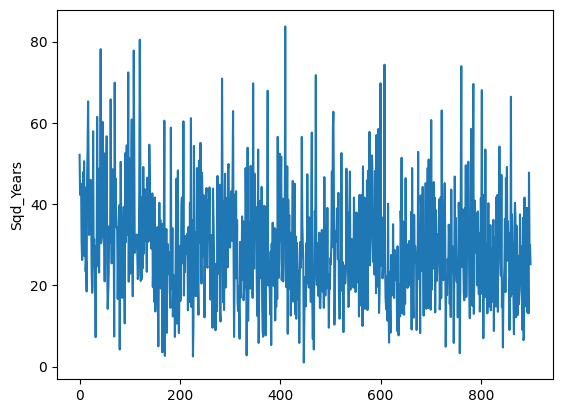

In [29]:
sns.lineplot(df['Sqd_Years'])

Since we have created the features now it is time to split the for training and testing

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.drop('Churn', axis= 1)

y = df['Churn']

In [32]:
X.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Tenure_Years,Years_Num_sites,Log_Total_Purchase,Sqd_Years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,old,57.76,9.311795,52.1284
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,old,71.50,9.385740,42.2500


In [33]:
y.head(2)

0    1
1    1
Name: Churn, dtype: int64

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.20,
    random_state=42
)

In [35]:
X_train.shape

(719, 13)

In [36]:
y_train.shape

(719,)

In [37]:
X_test.shape

(180, 13)

In [38]:
X_test.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Tenure_Years,Years_Num_sites,Log_Total_Purchase,Sqd_Years
332,Nicole Jacobson,41.0,8783.13,1,6.20,7.0,2009-08-10 16:00:31,"029 Bill Alley Apt. 087 West Kenneth, UT 32896","Hoffman, Leach and Smith",old,43.40,9.080702,38.4400
812,Kenneth Wilkerson,42.0,11670.32,0,5.51,7.0,2014-08-05 21:37:57,Unit 8005 Box 5636 DPO AA 90315-7695,"Aguilar, Kelly and Fuentes",Medium,38.57,9.364890,30.3601
745,Robin Sanchez,45.0,12200.96,1,4.70,6.0,2007-07-04 07:12:42,"2464 Cynthia Haven Apt. 333 Cynthiaport, FM 93220","Arellano, Smith and Lang",Medium,28.20,9.409352,22.0900


In [39]:
y_test.shape

(180,)

In [40]:
y_test.head()

332    0
812    0
745    0
244    0
39     1
Name: Churn, dtype: int64

Features are ready now we will make the Pipeline ready

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

Now we intialize the numeric and categorical features

In [42]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_Years,Years_Num_sites,Log_Total_Purchase,Sqd_Years
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76,9.311795,52.1284


In [43]:
numeric_features = ['Age', 'Total_Purchase', 'Years', 'Num_Sites', 'Years_Num_sites', 'Log_Total_Purchase', 'Sqd_Years']

catergorical_features = ['Account_Manager', 'Tenure_Years']

Now we will make the preprocessor ready

In [44]:
prepro = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(drop='if_binary'),
            catergorical_features
        )
    ]
)


preprocess is ready now we will create the pipeline

In [45]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [46]:
xgb_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [47]:
xgb_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [48]:
xgb_pred = xgb_pp.predict(X_test)

In [49]:
print(xgb_pred)

[0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0]


We have got the prediction now we will check how good our prediction with the help of Classification report


In [50]:
from sklearn.metrics import classification_report

In [51]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       148
           1       0.58      0.44      0.50        32

    accuracy                           0.84       180
   macro avg       0.73      0.68      0.70       180
weighted avg       0.83      0.84      0.84       180



In [52]:
param_grid = {
    'model__n_estimator':[50, 100,200],
    'model__max_depth':[3,5,7],
    'model__learning_rate':[0.01,0.1,0.2]
}

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
xgb_grid = GridSearchCV(
    xgb_pp,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [55]:
xgb_grid.fit(X_train,y_train)

d:\advanced-data-wrangling-lab\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:34:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimator': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [56]:
xgb_grid_pred = xgb_grid.predict(X_test)

In [57]:
print(xgb_grid.best_score_)

0.5931159420289854


In [58]:
print(classification_report(y_test, xgb_grid_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       148
           1       0.65      0.47      0.55        32

    accuracy                           0.86       180
   macro avg       0.77      0.71      0.73       180
weighted avg       0.85      0.86      0.85       180

